# Plano de parámetros · Método de Newton para p(z) = (z^2 - 1)(z - \u03bb)

Este notebook traduce a Python el cálculo del plano de parámetros del archivo Mathematica `fuentes mathematica/Plano_parametros_Newton.nb`.

Para cada parámetro complejo \u03bb en una rejilla rectangular, iteramos el punto crítico z0 = \u03bb/3 bajo el mapa de Newton de p(z) = (z^2 - 1)(z - \u03bb). Coloreamos según la raíz alcanzada (1, -1 o \u03bb) y modulamos la intensidad en función de la velocidad de convergencia (número de iteraciones), siguiendo el esquema usado en `TFMVictor_CuencaCubica.ipynb`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Polinomio p(z)=(z^2-1)(z-λ) y su paso de Newton N(z; λ)
def newton_step(z, lam):
    # Fórmula simplificada desde el notebook de Mathematica:
    # N(z; λ) = (2 z^3 - λ - z^2 λ) / (-1 + 3 z^2 - 2 z λ)
    z2 = z * z
    num = 2 * z * z2 - lam - z2 * lam
    den = -1 + 3 * z2 - 2 * z * lam
    out = np.empty_like(z, dtype=complex)
    # División segura para evitar warnings en puntos singulares
    np.divide(num, den, out=out, where=den != 0)
    # Donde el denominador es 0, dejamos el valor anterior (equivale a no avanzar)
    mask_sing = (den == 0)
    if np.any(mask_sing):
        out[mask_sing] = z[mask_sing]
    return out

# Clasificación por raíz alcanzada: devuelve 3 si ~1, 2 si ~-1, 1 si ~λ, 0 si ninguna
def root_position(z, lam, tol=1e-6):
    r0 = 1.0 + 0.0j
    r1 = -1.0 + 0.0j
    r2 = lam
    # Distancias a cada raíz
    d0 = np.abs(z - r0)
    d1 = np.abs(z - r1)
    d2 = np.abs(z - r2)
    res = np.zeros(z.shape, dtype=np.int32)
    res[d0 < tol] = 3
    res[(res == 0) & (d1 < tol)] = 2
    res[(res == 0) & (d2 < tol)] = 1
    return res

def cmyk_to_rgb(c, m, y, k):
    c = np.clip(np.asarray(c, dtype=float), 0.0, 1.0)
    m = np.clip(np.asarray(m, dtype=float), 0.0, 1.0)
    y = np.clip(np.asarray(y, dtype=float), 0.0, 1.0)
    k = np.clip(np.asarray(k, dtype=float), 0.0, 1.0)
    r = 1.0 - np.minimum(1.0, c + k)
    g = 1.0 - np.minimum(1.0, m + k)
    b = 1.0 - np.minimum(1.0, y + k)
    return np.stack([r, g, b], axis=-1)

# Colores con intensidad según la fracción (iteraciones/limite), inspirado en TFMVictor_CuencaCubica.ipynb
def colors_with_intensity(values):
    labels = values.astype(int)
    frac = np.modf(values)[0]  # parte fraccionaria ~ velocidad de convergencia
    pp = 0.4 * frac
    rgb = np.zeros(values.shape + (3,), dtype=float)
    mask3 = labels == 3
    mask2 = labels == 2
    mask1 = labels == 1
    # 3 -> rojo, 2 -> verde, 1 -> azul; K aumenta con pp para oscurecer
    if np.any(mask3):
        rgb[mask3] = cmyk_to_rgb(0.6 + pp[mask3], 0.0, 0.0, 2 * pp[mask3])
    if np.any(mask2):
        rgb[mask2] = cmyk_to_rgb(0.0, 0.6 + pp[mask2], 0.0, 2 * pp[mask2])
    if np.any(mask1):
        rgb[mask1] = cmyk_to_rgb(0.0, 0.0, 0.6 + pp[mask1], 2 * pp[mask1])
    # 0 (no convergido) -> negro por defecto
    return rgb

def compute_parameter_plane(points=512, limit=25, x_range=(-4.0, 4.0), y_range=(-4.0, 4.0), tol=1e-6):
    # Malla de parámetros λ = x + i y
    xs = np.linspace(x_range[0], x_range[1], points)
    ys = np.linspace(y_range[1], y_range[0], points)  # de max a min para origin='upper'
    lam = xs[None, :] + 1j * ys[:, None]

    # Punto crítico z0 = λ/3 (soluciones[[1]] en Mathematica)
    current = lam / 3.0

    root_ids = np.zeros(lam.shape, dtype=np.int32)
    iter_counts = np.zeros(lam.shape, dtype=np.int32)

    for _ in range(limit):
        active = (root_ids == 0)
        if not np.any(active):
            break
        iter_counts[active] += 1
        # Paso de Newton dependiente de λ por punto
        updated = np.empty_like(current)
        updated[active] = newton_step(current[active], lam[active])
        current[active] = updated[active]
        # Clasificar puntos que han convergido a alguna raíz
        new_ids = np.zeros_like(root_ids)
        new_ids[active] = root_position(current[active], lam[active], tol=tol)
        mask = (new_ids > 0) & (root_ids == 0)
        root_ids[mask] = new_ids[mask]

    # Valor para color: etiqueta entera + fracción por iteraciones
    values = root_ids.astype(float) + iter_counts / (limit + 0.001)
    return xs, ys, values

def show_plane(xs, ys, values, title=None):
    colors = colors_with_intensity(values)
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(colors, origin='upper', extent=[xs.min(), xs.max(), ys.min(), ys.max()])
    ax.set_xlabel('Re(λ)')
    ax.set_ylabel('Im(λ)')
    if title:
        ax.set_title(title)
    plt.show()


## Parámetros por defecto (como en el notebook de Mathematica)
- Resolución: 512×512
- Iteraciones máximas: 25
- Ventana: Re(\u03bb), Im(\u03bb) en [-4, 4]


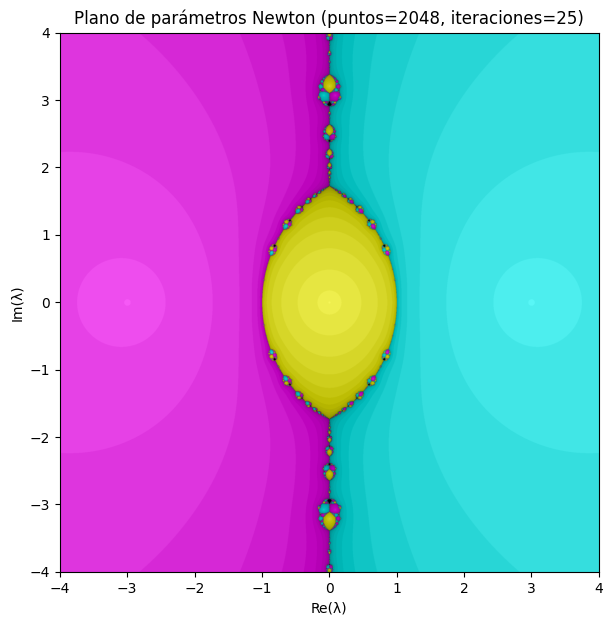

Imagen exportada a: img/plan_param_newton_1.png


In [5]:
import os

points = 2048
limit = 25
x_range = (-4.0, 4.0)
y_range = (-4.0, 4.0)

xs, ys, values = compute_parameter_plane(points=points, limit=limit, x_range=x_range, y_range=y_range, tol=1e-6)
show_plane(xs, ys, values, title=f'Plano de parámetros Newton (puntos={points}, iteraciones={limit})')

# Exportar imagen
os.makedirs('img', exist_ok=True)
colors = colors_with_intensity(values)
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(colors, origin='upper', extent=[xs.min(), xs.max(), ys.min(), ys.max()])
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='both', which='both', length=5, width=1)
plt.savefig('img/plan_param_newton_1.png', dpi=300, bbox_inches='tight')
plt.close()

print("Imagen exportada a: img/plan_param_newton_1.png")

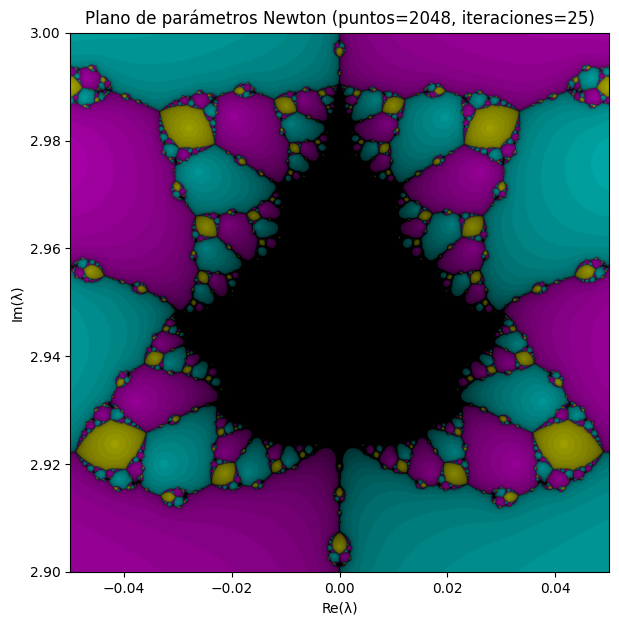

Imagen exportada a: img/plan_param_newton_2.png


In [6]:
import os

points = 2048
limit = 25
x_range = (-0.05, 0.05)
y_range = (2.9, 3.0)

xs, ys, values = compute_parameter_plane(points=points, limit=limit, x_range=x_range, y_range=y_range, tol=1e-6)
show_plane(xs, ys, values, title=f'Plano de parámetros Newton (puntos={points}, iteraciones={limit})')

# Exportar imagen
os.makedirs('img', exist_ok=True)
colors = colors_with_intensity(values)
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(colors, origin='upper', extent=[xs.min(), xs.max(), ys.min(), ys.max()])
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='both', which='both', length=5, width=1)
plt.savefig('img/plan_param_newton_2.png', dpi=300, bbox_inches='tight')
plt.close()

print("Imagen exportada a: img/plan_param_newton_2.png")